# Deutsch's Algorithm

Deutsch's algorithm is a simple quantum algorithm and serves as a foundational proof-of-concept that quantum computers can solve certain problems faster than classical computers. 

**The Problem:**
Imagine a black-box function (an "oracle"), $f(x)$, that takes a single bit as input (0 or 1) and outputs a single bit (0 or 1). There are four possible functions of this type:
* **Constant Functions:** The output is the same regardless of the input.
    * $f(0) = 0$ and $f(1) = 0$
    * $f(0) = 1$ and $f(1) = 1$
* **Balanced Functions:** The output is different for each input (exactly half 0s and half 1s).
    * $f(0) = 0$ and $f(1) = 1$ (Identity)
    * $f(0) = 1$ and $f(1) = 0$ (Bit-flip)

**The Goal:** Determine if the function is constant or balanced, essentially performing XOR on the string $f(0)f(1)$ also known as parity 
* **Classically:** We must query the function twice (check $f(0)$, then check $f(1)$) to know for sure.
* **Quantumly:** Deutsch's algorithm allows us to determine this with exactly **one** query to the quantum oracle.

In [1]:
# Import standard Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Set up the local simulator
simulator = AerSimulator()

## Step 1: Defining the Quantum Oracles

A quantum oracle $U_f$ applies the function $f(x)$ to our qubits. To make it reversible, we use two qubits: a data qubit ($|x\rangle$) and an ancilla/target qubit ($|y\rangle$). 
$U_f$ takes the value of the function $f$ for the classical state of the top/rightmost qubit and XORs it onto the bottom/leftmost qubit

Let's define the four possible oracles as standalone quantum circuits.

Balanced Identity Oracle:


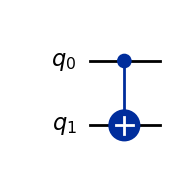

In [2]:
def get_constant_0_oracle():
    """Oracle for f(x) = 0 (Constant)"""
    qc = QuantumCircuit(2)
    # Does nothing to the target qubit since f(x) is always 0
    qc.name = "Oracle (Const 0)"
    return qc

def get_constant_1_oracle():
    """Oracle for f(x) = 1 (Constant)"""
    qc = QuantumCircuit(2)
    # Flips the target qubit regardless of the control qubit
    qc.x(1) 
    qc.name = "Oracle (Const 1)"
    return qc

def get_balanced_id_oracle():
    """Oracle for f(x) = x (Balanced Identity)"""
    qc = QuantumCircuit(2)
    # Flips the target qubit only if the control qubit is |1>
    qc.cx(0, 1) 
    qc.name = "Oracle (Bal ID)"
    return qc

def get_balanced_not_oracle():
    """Oracle for f(x) = NOT x (Balanced Bit-flip)"""
    qc = QuantumCircuit(2)
    # Flips target if control is |0>
    qc.x(0)
    qc.cx(0, 1)
    qc.x(0)
    qc.name = "Oracle (Bal NOT)"
    return qc

# Let's visualize one of our balanced oracles
print("Balanced Identity Oracle:")
display(get_balanced_id_oracle().draw('mpl'))

## Step 2: The Deutsch Algorithm Circuit

Now we build the framework that surrounds the oracle. The algorithm proceeds in the following steps:
1.  **Initialization:** Start with the data qubit (qubit 0) in the state $|0\rangle$ and the ancilla qubit (qubit 1) in the state $|1\rangle$.
2.  **Superposition:** Apply Hadamard ($H$) gates to both qubits. This creates a superposition of all possible inputs and puts the ancilla into the $|-\rangle$ state, enabling the phase kickback mechanism.
3.  **Oracle:** Apply the $U_f$ gate. Due to phase kickback, the evaluation of $f(x)$ alters the relative phase of the data qubit.
4.  **Interference:** Apply a final $H$ gate to the data qubit.
5.  **Measurement:** Measure the data qubit. 
    * If the result is **0**, the function is **Constant**.
    * If the result is **1**, the function is **Balanced**.

Deutsch's Algorithm Circuit:


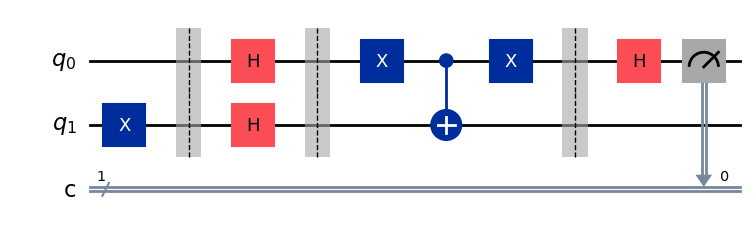

In [3]:
def deutsch_algorithm(oracle):
    """
    Constructs the Deutsch algorithm circuit using a provided oracle.
    """
    # 2 qubits (data, ancilla) and 1 classical bit for measurement
    qc = QuantumCircuit(2, 1)
    
    # 1. Initialization: Set ancilla qubit (q1) to |1>
    qc.x(1)
    qc.barrier()
    
    # 2. Superposition: Apply H-gates to both qubits
    qc.h(0)
    qc.h(1)
    qc.barrier()
    
    # 3. Apply the Oracle
    qc.compose(oracle, inplace=True)
    qc.barrier()
    
    # 4. Interference: Apply H-gate to the data qubit (q0)
    qc.h(0)
    
    # 5. Measure the data qubit
    qc.measure(0, 0)
    
    return qc

# Let's test building the circuit with our Balanced NOT oracle
test_circuit = deutsch_algorithm(get_balanced_not_oracle())
print("Deutsch's Algorithm Circuit:")
display(test_circuit.draw('mpl'))

## Step 3: Running the Algorithm

To prove the algorithm works, we will run all four possible oracles through our `deutsch_algorithm` function and execute them on the AerSimulator. 

Because this is a deterministic quantum algorithm, a single shot is technically enough to get the answer. However, we will use 1024 shots to clearly show the probability distribution is 100% focused on the correct answer.

* **Expected Constant outcome:** 100% probability of measuring `0`.
* **Expected Balanced outcome:** 100% probability of measuring `1`.

Oracle: Constant 0 | Measured: 0 | Conclusion: Constant
Oracle: Constant 1 | Measured: 0 | Conclusion: Constant
Oracle: Balanced ID | Measured: 1 | Conclusion: Balanced
Oracle: Balanced NOT | Measured: 1 | Conclusion: Balanced


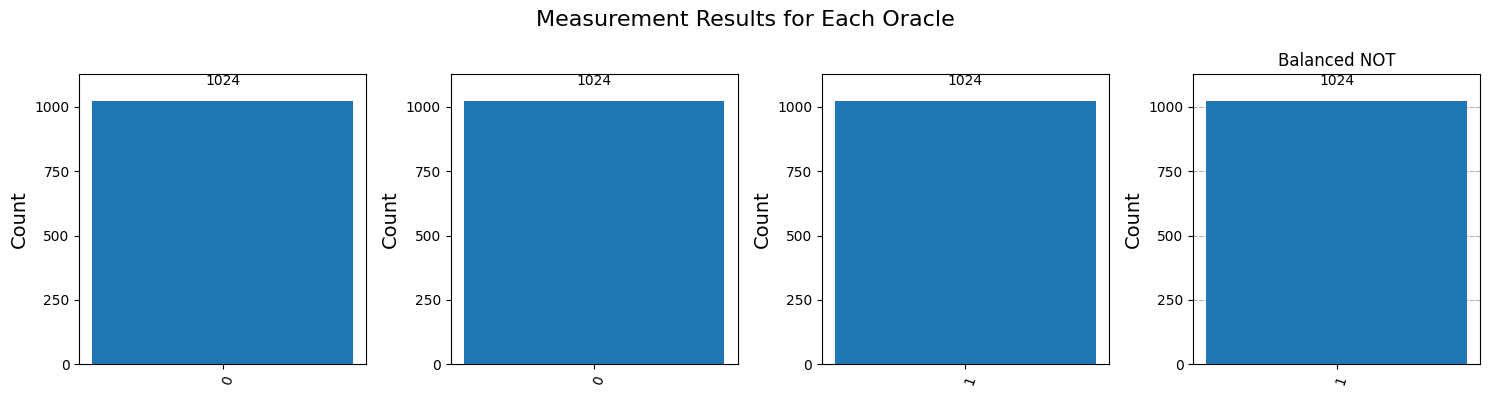

In [4]:
# Dictionary of our oracles
oracles = {
    "Constant 0": get_constant_0_oracle(),
    "Constant 1": get_constant_1_oracle(),
    "Balanced ID": get_balanced_id_oracle(),
    "Balanced NOT": get_balanced_not_oracle()
}

results_data = {}

for name, oracle in oracles.items():
    # Build the circuit for the current oracle
    circuit = deutsch_algorithm(oracle)
    
    # Transpile the circuit for the simulator
    transpiled_circuit = transpile(circuit, simulator)
    
    # Run the circuit on the simulator
    job = simulator.run(transpiled_circuit, shots=1024)
    result = job.result()
    
    # Get the counts (measurement outcomes)
    counts = result.get_counts()
    results_data[name] = counts
    
    # Print the conclusion
    measured_state = list(counts.keys())[0]
    conclusion = "Constant" if measured_state == '0' else "Balanced"
    print(f"Oracle: {name} | Measured: {measured_state} | Conclusion: {conclusion}")

# Plotting the histograms side-by-side
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle('Measurement Results for Each Oracle', fontsize=16)

for i, (name, counts) in enumerate(results_data.items()):
    plot_histogram(counts, ax=ax[i], title=name)

plt.tight_layout()
plt.show()